In [1]:
# вычисление зависимости
# дифференциального сечения рассеяния
# заряженной частицы на неподвижном
# электрическом заряде
# от прицельного параметра

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение функции solve_ivp из библиотеки scipy.integrate
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение библиотеки math
import math

# подключаем функцию CubicSplain,
# возвращающей решение задачи кубической
# сплайн-интерполяции заданной таблично
# функции, зависящей от одной переменной
from scipy.interpolate import CubicSpline


In [2]:
# Ячейка № 2

# задание значений глобальных переменных:

# обезразмеренного значения
# заряда рассеиваемой частицы
q = 2

# обезразмеренного значения
# массы рассеиваемой частицы
M = 4

# обезразмеренного значения
# заряда рассеивающего центра
Q = 79


# задание функции, возвращающей значения
# координат вектора-функции,
# стоящей в левой части системы (6.17)
def CenterPole(t, z):
    # вычисление значения параметра K в (6.17)
    K = 1.53 * q * Q / M

    # инициализация массива, используемого
    # для хранения значений первых производных в (6.17)
    dy = np.zeros(4)

    # вычисление координат вектора-функции,
    # стоящей в правой части (4.30)
    dy[0] = z[1]
    dy[1] = K * z[0] / (z[0] ** 2 + z[2] ** 2) ** (3 / 2)
    dy[2] = z[3]
    dy[3] = K * z[2] / ((z[0]) ** 2 + z[2] ** 2) ** (3 / 2)

    return dy

In [3]:
# Ячейка № 3

# вычисление численного решения
# системы ОДУ (6.17)

# задание начальных условий СДУ (6.17):

# задание значения абсциссы
# начальной точки
x0 = -(10**6)

# задание значения ординаты
# начальной точки
y0 = 4 * 10**4

# задание значения проекции
# начальной скорости на ось ОХ
vx0 = 0.1

# задание значения проекции
# начальной скорости на ось ОY
vy0 = 0

# задание длительности временного интервала,
# на котором вычисляется численное решение СДУ (6.17)
Tmax = 2 * 10**7

# задание максимального значения
# шага интегрирования СДУ (6.17)
N = 5000
dt = Tmax / N

# задание параметров сетки по прицельному параметру
Nr = 100
Ymin = 0
Ymax = 10**5
dy = (Ymax - Ymin) / (Nr - 1)

# инициализация массивов Chi, Ro
Chi = np.zeros(Nr)
Ro = np.zeros(Nr)

# вычисление значений зависимости
# угла рассеяния от прицельного параметра
for i in range(Nr):
    # вычисление текущего значения
    # прицельного параметра
    Ro[i] = Ymax - dy * i

    # вычисление для данного значения
    # прицельного параметра
    # численного решения СДУ (6.17)
    Solv = solve_ivp(CenterPole, [0, Tmax], [x0, vx0, Ro[i], vy0], max_step=dt)

    # копирование мгновенных значений
    # проекций скорости частицы на ось ОХ
    # в массив vx
    vx = Solv.y[1, :]

    # копирование мгновенных значений
    # проекций скорости частицы на ось ОY
    # в массив vy
    vy = Solv.y[3, :]

    # вычисление для данного значения
    # прицельного параметра
    # значений угла рассеяния
    Chi[i] = math.acos(Solv.y[1, N] / np.sqrt(Solv.y[1, N] ** 2 + Solv.y[3, N] ** 2))

# интерполяция зависимости
# прицельного параметра
# от угла рассеяния

# задание функции, возвращающей
# значения интерполяционного сплайна
f = CubicSpline(Chi, Ro)

# задание значений
# координат узлов интерполяции
x1 = np.min(Chi)
x2 = np.max(Chi)
Chi_interp = np.linspace(x1, x2, 500)
dChi = Chi_interp[1] - Chi_interp[0]

# вычисление интерполированных значений
# зависимости прицельного параметра от
# от угла рассеяния
Ro_interp = f(Chi_interp)

# вычисление значений
# дифференциального сечения рассеяния
# в соответствие с (6.24)
dRo = np.abs(np.diff(Ro_interp) / dChi)
N1 = len(dRo)
dSigma = np.zeros(N1)
for i in range(N1):
    dSigma[i] = 2 * np.pi * Ro_interp[i] * dRo[i]


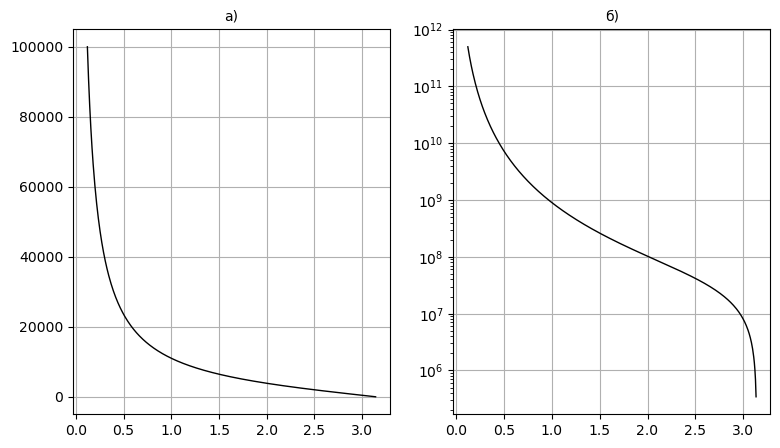

In [4]:
# Ячейка № 4

# визуализация результатов интерполяции
# зависимостей прицельного параметра
#  и зависимости дифференциального сечения рассеяния
# от угла рассеяния

fig = plt.figure(figsize=(9, 5))

# визуализация результатов интерполяции
# зависимости прицельного параметра от
# угла рассеяния
ax = plt.subplot(1, 2, 1)
ax.plot(Chi_interp, Ro_interp, "-k", lw=1)
ax.grid(True)
plt.title(r"а)", fontsize=10)

# визуализация зависимости
# дифференциального сечения рассеяния
# от угла рассеяния
ax = plt.subplot(1, 2, 2)
ax.semilogy(Chi_interp[0:N1], dSigma[0:N1], "-k", lw=1)
ax.grid(True)
plt.title(r"б)", fontsize=10)

plt.show()